# Progetto di Architetture Dati

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
census_income = fetch_ucirepo(id=20) 
  
# data (as pandas dataframes) 
X = census_income.data.features  # type: ignore
y = census_income.data.targets  # type: ignore


In [3]:
import pandas as pd
from pandas import DataFrame
import phik
from phik.report import plot_correlation_matrix
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import seaborn as sns

 # Analisi esplorativa dei dati (EDA)

Il dataset si compone di 48.842 istanze e 14 features, di cui 6 variabili sono numeriche (indicate  con tipo `int64`) e 8 sono categoriche (indicate con tipo `str`). La variabile target è "income", che indica se il reddito di una persona è superiore a 50K all'anno.

In [4]:
X.info()
print("--------------------------------------------------------")
y.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      47876 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48568 non-null  str  
dtypes: int64(6), str(8)
memory usage: 5.2 MB
--------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 1 columns):
 #   Column  N

In [5]:
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


### Variabili numeriche
Le variabili numeriche presenti nel dataset sono:
- `age`: età dell'individuo espressa in anni
- `fnlwgt`: È un peso statistico; indica quante persone reali nella popolazione americana sono rappresentate da questo singolo record.
- `education-num`: Gli anni totali di studio completati
- `capital-gain`: guadagni finanziari extra derivanti da investimenti o vendite di proprietà 
- `capital-loss`: Le perdite finanziarie subite su investimenti o vendite di proprietà
- `hours-per-week`: Il numero medio di ore lavorate ogni settimana.

Analizziamo le distribuzioni di ciascuna variabile.

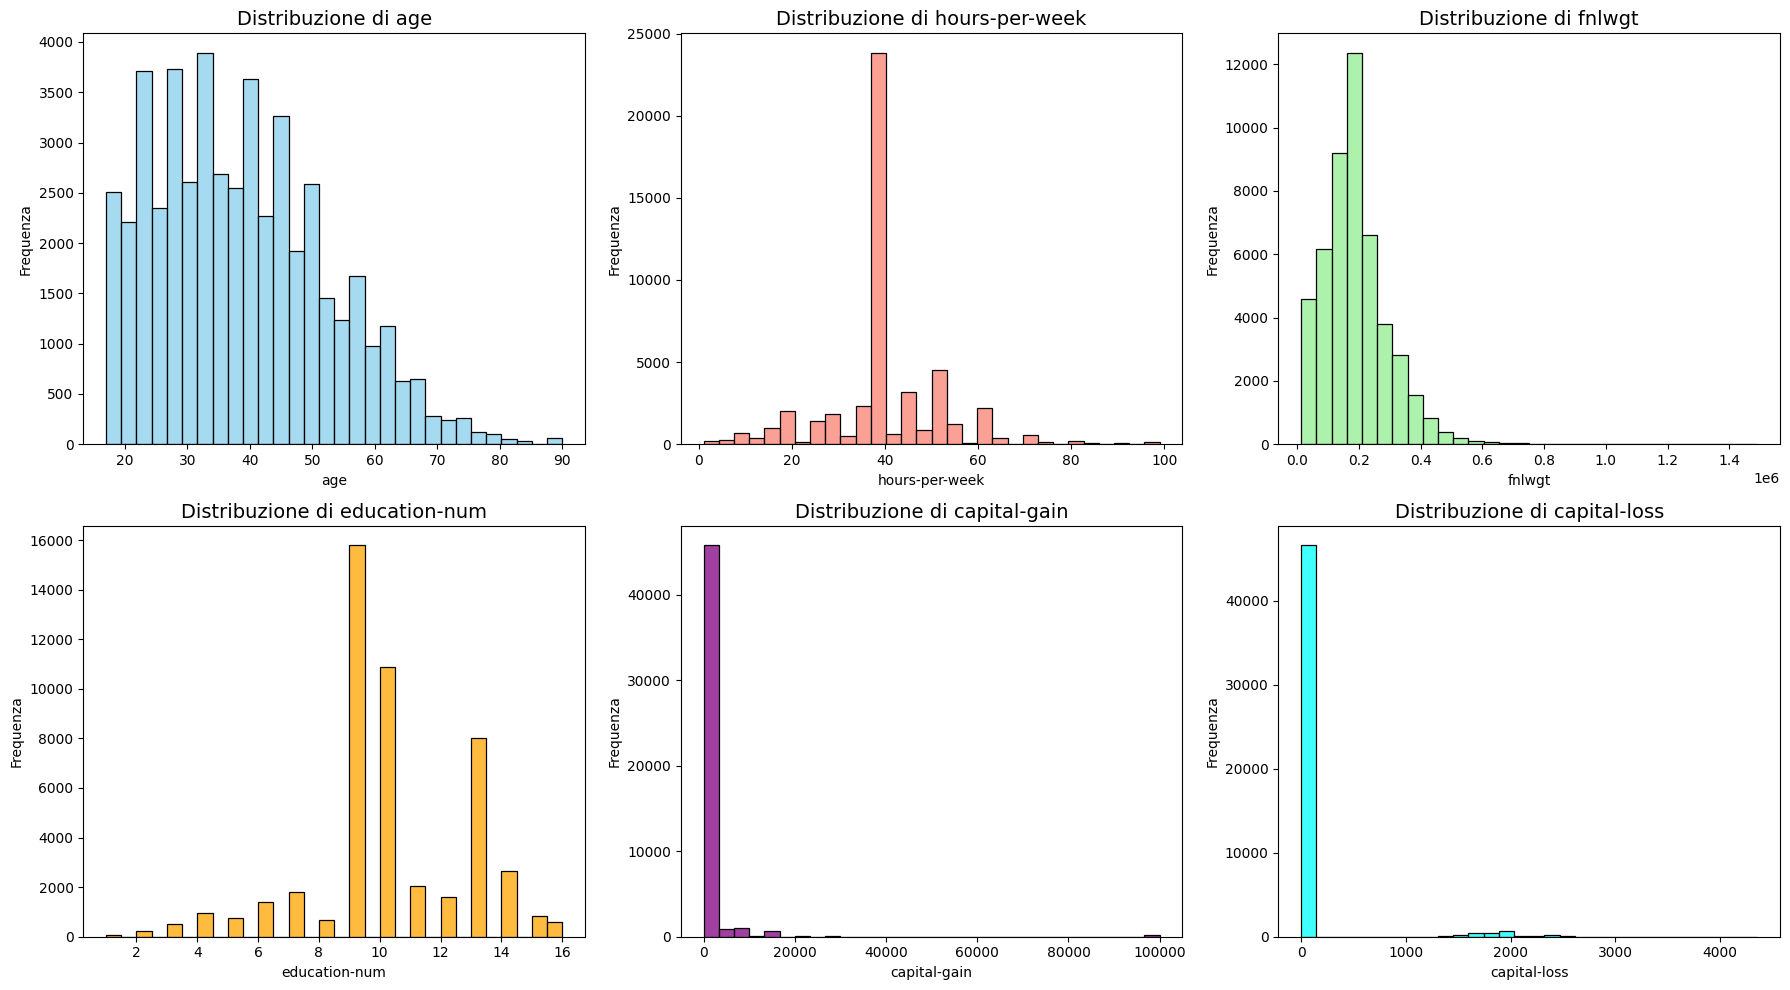

In [6]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))

num_var = ['age', 'hours-per-week', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss']
colors = ['skyblue', 'salmon', 'lightgreen', 'orange', 'purple', 'cyan']

axes_flat = axes.flatten()

for i, var in enumerate(num_var):
    sns.histplot(data=X, x=var, bins=30, ax=axes_flat[i], color=colors[i], edgecolor='black') # type: ignore
    
    axes_flat[i].set_title(f'Distribuzione di {var}', fontsize=14)
    axes_flat[i].set_xlabel(var)
    axes_flat[i].set_ylabel('Frequenza')

plt.tight_layout()
plt.show()

Dai grafici delle variabili numeriche, si osserva che:
- `age` mostra una distribuzione più o meno normale, con una discesa graduale verso le età più avanzate.
- `hours-per-week` mostra valori molto bassi, con un picco intorno alle 40 ore, che è tipico per una settimana lavorativa standard.
- `fnlwgt` è distribuito solo su una parte del grafico, interrompendosi poco prima di 0.8.
- `education-num` mostra tre picchi distinti, corrispondenti a diversi livelli di istruzione, in particolare a 9, 10 e 13 anni di istruzione.
- `capital-gain` e `capital-loss` mostrano una distribuzione altamente asimmetrica, con la maggior parte dei valori concentrati vicino a zero e pochi valori che rappresentano guadagni o perdite significative.

### Variabili categoriche
Le variabili categoriche presenti nel dataset sono:

- `workclass`: la categoria contrattuale o la natura giuridica del datore di lavoro (es. dipendente privato, statale, autonomo).
- `education`: il massimo titolo di studio conseguito.
- `marital-status`: lo stato civile della persona al momento del censimento (es. sposato, divorziato, mai sposato).
- `occupation`: la mansione specifica o la qualifica professionale vera e propria dell'individuo (es. vendite, artigianato, dirigenza).
- `relationship`: il ruolo ricoperto dalla persona all'interno del nucleo familiare (es. marito, moglie, figlio).
- `race`: l'etnia o il gruppo razziale di appartenenza.
- `sex`: il genere biologico della persona (Maschio o Femmina).
- `native-country`: la nazione di nascita o di origine dell'individuo.

Analizziamo la distribuzione di ciascuna variabile.

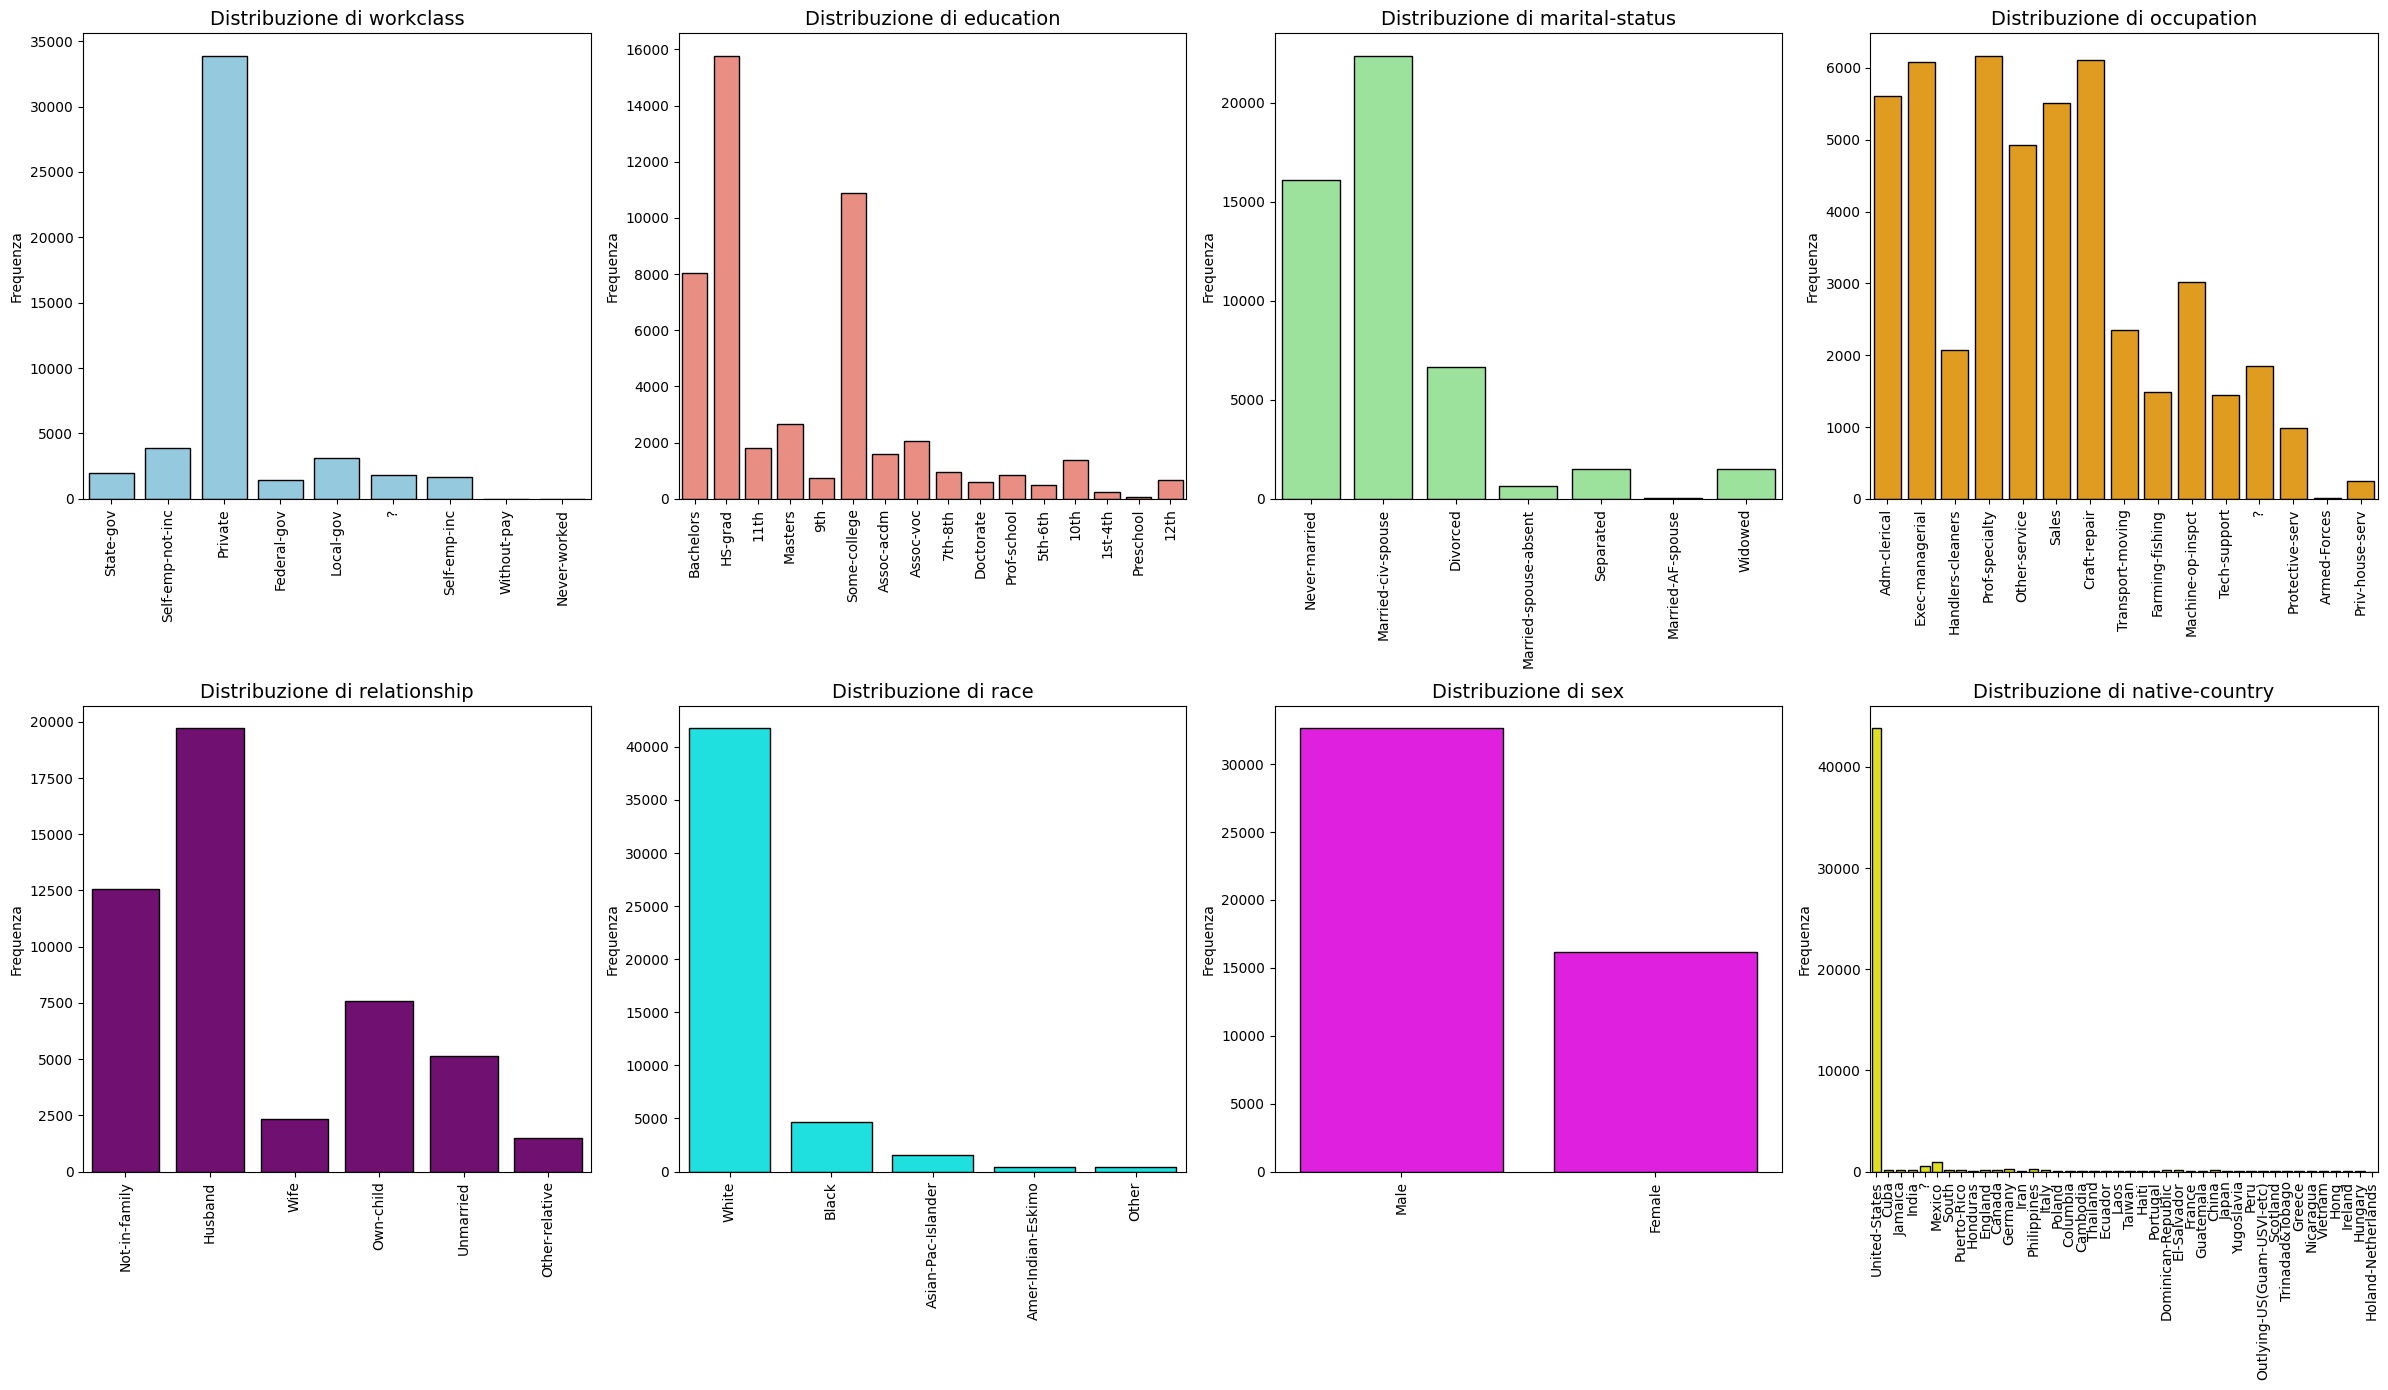

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(24, 14))

cat_var = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
colors = ['skyblue', 'salmon', 'lightgreen', 'orange', 'purple', 'cyan', 'magenta', 'yellow']

axes_flat = axes.flatten()

for i, var in enumerate(cat_var):
    sns.countplot(data=X, x=var, ax=axes_flat[i], color=colors[i], edgecolor='black')
    
    axes_flat[i].set_title(f'Distribuzione di {var}', fontsize=14)
    axes_flat[i].set_xlabel('')
    axes_flat[i].set_ylabel('Frequenza')
    
    axes_flat[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Dai grafici delle variabili categoriche, si osserva che:
- `workclass` è dominato da dipendenti privati (Private).
- `education` il titolo di studio più diffuso è il diploma di scuola superiore (HS-grad). Seguono un elevato numero di individui con studi universitari parziali/incompleti (Some-college) e persone in possesso di una laurea di primo livello (Bachelors).
- `marital-status` è dominato da persone sposate (Married-civ-spouse) e da persone che non si sono mai sposate (Never-married).
- `occupation` mostra una prevalenza di persone impiegate in mansioni di artigianato (Craft-repair) o carriere professionali (Prof-specialty).
- `relationship` è dominato da persone che ricoprono il ruolo di marito (Husband) e da persone che non sono in una relazione familiare (Not-in-family).
- `race` mostra una prevalenza di persone di etnia bianca (White), seguita da persone di etnia nera (Black).
- `sex` è dominato da persone di genere maschile (Male).
- `native-country` mostra una prevalenza di persone nate negli Stati Uniti (United-States), seguite da persone nate in India (India) e in Messico (Mexico).

Per concludere l'analisi esplorativa, mostriamo la distribuzione della variabile target `income`. Questa restituisce due valori: `<=50K` e `>50K`. Notiamo che la maggior parte delle persone nel dataset guadagna meno di 50K all'anno, con una distribuzione sbilanciata a favore della classe `<=50K`.

Bisogna tenere conto di una formattazione errata del target, dal momento che restituisce 4 risultati causati da un simbolo `.` presente alla fine di due risultati. Nella fase di preprocessing, i due risultati ridondanti verranno unificati in `<=50K` e `>50K`, rispettivamente.

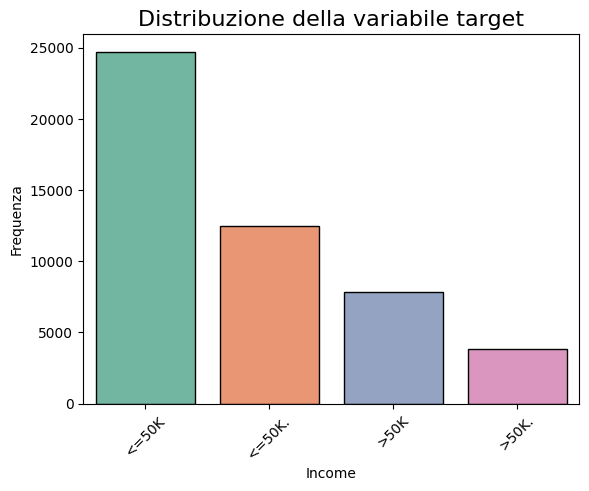

Percentuale di persone con income <=50K: 76.1%
Percentuale di persone con income  >50K: 23.9%


In [8]:
values = y['income'].value_counts()
sns.barplot(x=values.index, y=values.values, palette='Set2', edgecolor='black', hue=values.index)
plt.title('Distribuzione della variabile target', fontsize=16)
plt.xlabel('Income')
plt.ylabel('Frequenza')
plt.xticks(rotation=45)
plt.show()

income_clean = y['income'].replace({'<=50K.': '<=50K', '>50K.': '>50K'})
perc = income_clean.value_counts(normalize=True) * 100
print("Percentuale di persone con income <=50K: {:.1f}%".format(perc['<=50K']))
print("Percentuale di persone con income  >50K: {:.1f}%".format(perc['>50K']))

## Correlazione tra variabili
In questa sezione verifichiamo l'esistenza di correlazioni tra le feature del dataset. Lo scopo è identificare eventuali relazioni tra le variabili che potrebbero influenzare la costruzione del modello di classificazione. 

**Una nota importante:** La matrice di correlazione prevede l'analisi delle sole variabili numeriche (dal momento che la scala di cui fa uso è quella di Pearson). Per ovviare al problema, è stata usata una libreria apposita chiamata **phik**, realizzata appositamente per calcolare la correlazione tra variabili categoriche e numeriche.

interval columns not set, guessing: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'income']


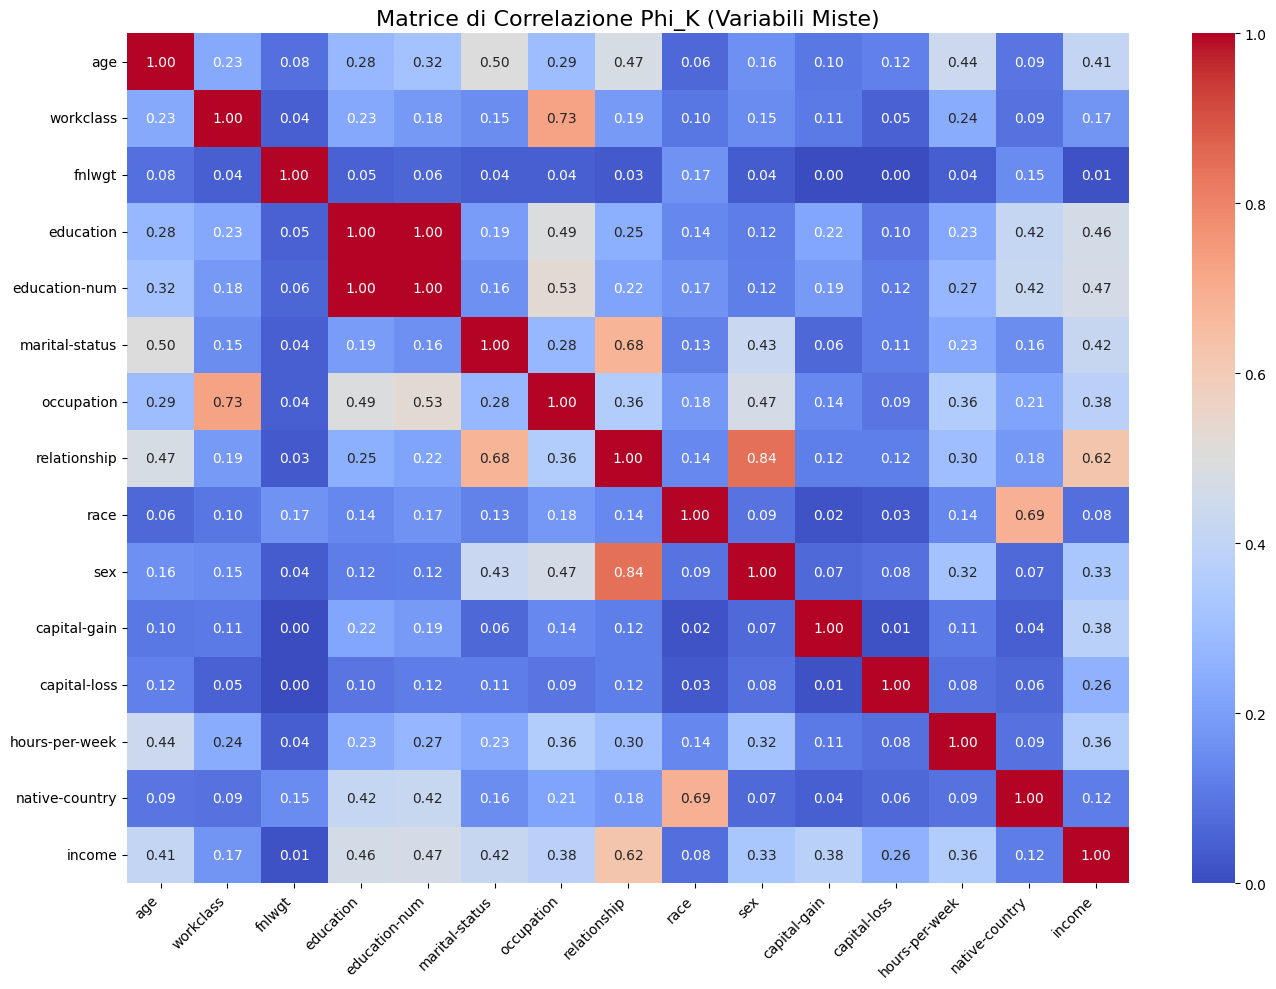

In [9]:
y_mapped = y['income'] = y['income'].replace({'<=50K.': '<=50K', '>50K.': '>50K'})
y_mapped = y_mapped.map({'<=50K': 0, '>50K': 1})
complete_dataset = pd.concat([X, y_mapped], axis=1)
phik_matrix = complete_dataset.phik_matrix()

plt.figure(figsize=(14, 10))
sns.heatmap(phik_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=0, vmax=1)
plt.title('Matrice di Correlazione Phi_K (Variabili Miste)', fontsize=16)

plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Valori nulli presenti nel dataset
Nel dataset sono presenti 2203 valori nulli con valore `NaN`, distribuiti nelle variabili `workclass`, `occupation` e `native-country`.

Per sicurezza, è stato verificata la presenza di valori nulli rappresentati con il simbolo "?" e sono stati trovati 4262 valori "?" distribuiti nelle stesse variabili.

In [10]:
print("Valori nulli in X:")
print(X.isnull().sum())

print("\nValori nulli formattati con '?':")
print((X == '?').sum())

Valori nulli in X:
age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
dtype: int64

Valori nulli formattati con '?':
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
dtype: int64


Nel seguente script vengono contate le righe contenenti almeno un valore nullo, sia rappresentato con `NaN` che con `?`. In questo modo si stabilisce quali righe del dataset sono incomplete, in modo da stabilire se è necessario rimuoverle o se è possibile sostituire i valori mancanti.

In [ ]:
import pandas as pd

nan_cells = X.isnull().sum().sum()
qmark_cells = (X == '?').sum().sum()
print(f"Celle NaN: {nan_cells}")
print(f"Celle con '?': {qmark_cells}")
print(f"Totale celle nulle: {nan_cells + qmark_cells}")

X.replace('?', pd.NA, inplace=True)

null_pct_per_column = (X.isnull().sum() / len(X)) * 100
print("\n--- Percentuale di valori nulli per colonna ---")
print(null_pct_per_column[null_pct_per_column > 0].round(2).astype(str) + '%')

rows_with_null = X.isnull().any(axis=1).sum()
rows_with_null_pct = (rows_with_null / len(X)) * 100
print(f"\nRighe con almeno un valore nullo: {rows_with_null}")
print(f"Percentuale di righe con almeno un nullo: {rows_with_null_pct:.2f}%")

Celle NaN: 2203
Celle con '?': 4262
Totale celle nulle: 6465

--- Percentuale di valori nulli per colonna ---
workclass         5.73%
occupation        5.75%
native-country    1.75%
dtype: str

Righe con almeno un valore nullo: 3620
Percentuale di righe con almeno un nullo: 7.41%


In totale, la percentuale di righe con almeno un valore nullo è del 7.41%.

## Preprocessing dei dati
In questa fase, vengono eseguite alcune operazioni di preprocessing sui dati, in modo da prepararli per la fase di modellazione.

### Sostituzione dei valori nulli
Per uniformare i dati, i valori "?" rilevati durante l'analisi esplorativa, sono stati sostituiti con `NaN`. Successivamente, sono stati sostituiti tutti i record che contenevano almeno un valore `NaN` con la dicitura *Unknown*. In questo modo, si è evitata la perdita di dati, mantenendo comunque l'informazione che alcuni record contengono valori mancanti.

In [12]:
X.replace('?', pd.NA, inplace=True)

print("Totale valori nulli prima della sostituzione:", X.isnull().sum().sum())

null_columns = ['workclass', 'occupation', 'native-country']

for col in null_columns:
    X[col] = X[col].fillna('Unknown')

print("Totale valori nulli rimasti:", X.isnull().sum().sum())
print(f"Istanze 'Unknown' in workclass: {X['workclass'].value_counts().get('Unknown', 0)}")
print(f"Istanze 'Unknown' in occupation: {X['occupation'].value_counts().get('Unknown', 0)}")
print(f"Istanze 'Unknown' in native-country: {X['native-country'].value_counts().get('Unknown', 0)}")

Totale valori nulli prima della sostituzione: 6465
Totale valori nulli rimasti: 0
Istanze 'Unknown' in workclass: 2799
Istanze 'Unknown' in occupation: 2809
Istanze 'Unknown' in native-country: 857


### Unificazione e Trasformazione della variabile target
Al momento, la variabile `target` restituisce quattro valori: `<=50K`, `>50K`, `<=50K.`, `>50K.`. Per uniformare i dati, i valori `<=50K.` e `>50K.` sono stati unificati rispettivamente in `<=50K` e `>50K`. A seguire, la variabile target è stata trasformata in formato numerico, con `<=50K` mappato a 0 e `>50K` mappato a 1.

Dal grafico notiamo un netto sbilanciamento tra le due classi, il 76.1% delle persone guadagna meno di 50K all'anno, mentre solo il 23.9% guadagna più di 50K all'anno. 

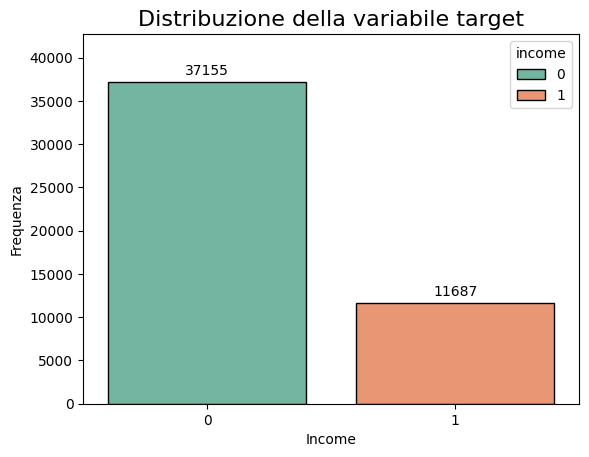

Percentuale di persone che guadagnano <=50K: 76.1 %
Percentuale di persone che guadagnano >50K: 23.9 %


In [13]:
y_mapped = y['income'] = y['income'].replace({'<=50K.': '<=50K', '>50K.': '>50K'})
y_mapped = y_mapped.map({'<=50K': 0, '>50K': 1})
y_mapped = y_mapped.loc[X.index]
values = y_mapped.value_counts()

ax = sns.barplot(x=values.index, y=values.values, palette='Set2', edgecolor='black', hue=values.index)

for container in ax.containers:
    ax.bar_label(container, padding=3) # type: ignore


plt.title('Distribuzione della variabile target', fontsize=16)
plt.xlabel('Income')
plt.ylabel('Frequenza')
plt.margins(y=0.15) 
plt.show()

print("Percentuale di persone che guadagnano <=50K:", (values[0] / values.sum()).round(3) * 100,"%")
print("Percentuale di persone che guadagnano >50K:", (values[1] / values.sum()).round(3) * 100,"%")

### Riduzione del dataset
Per ridurre il dataset, sono state rimosse le variabili `fnlwgt`, `race` e `native-country`, in quanto presentano una correlazione molto bassa con la variabile target `income`.

La variabile `education` è stata rimossa, in quanto è completamente correlata con `education-num`, e quest'ultima, essendo numerica, è più adatta per la modellazione rispetto alla sua controparte categorica.

Anche la variabile `relationship` è stata rimossa, in quanto altamente correlata con `sex` e `marital-status`, e la prima, essendo più semplice da interpretare, è più adatta per la modellazione.

La variabile `workclass` è stata rimossa, in quanto mediamente correlata con `occupation`, e quest'ultima, essendo più descrittiva dato che specifica il lavoro della persona, è più adatta per la modellazione.

interval columns not set, guessing: ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'income']


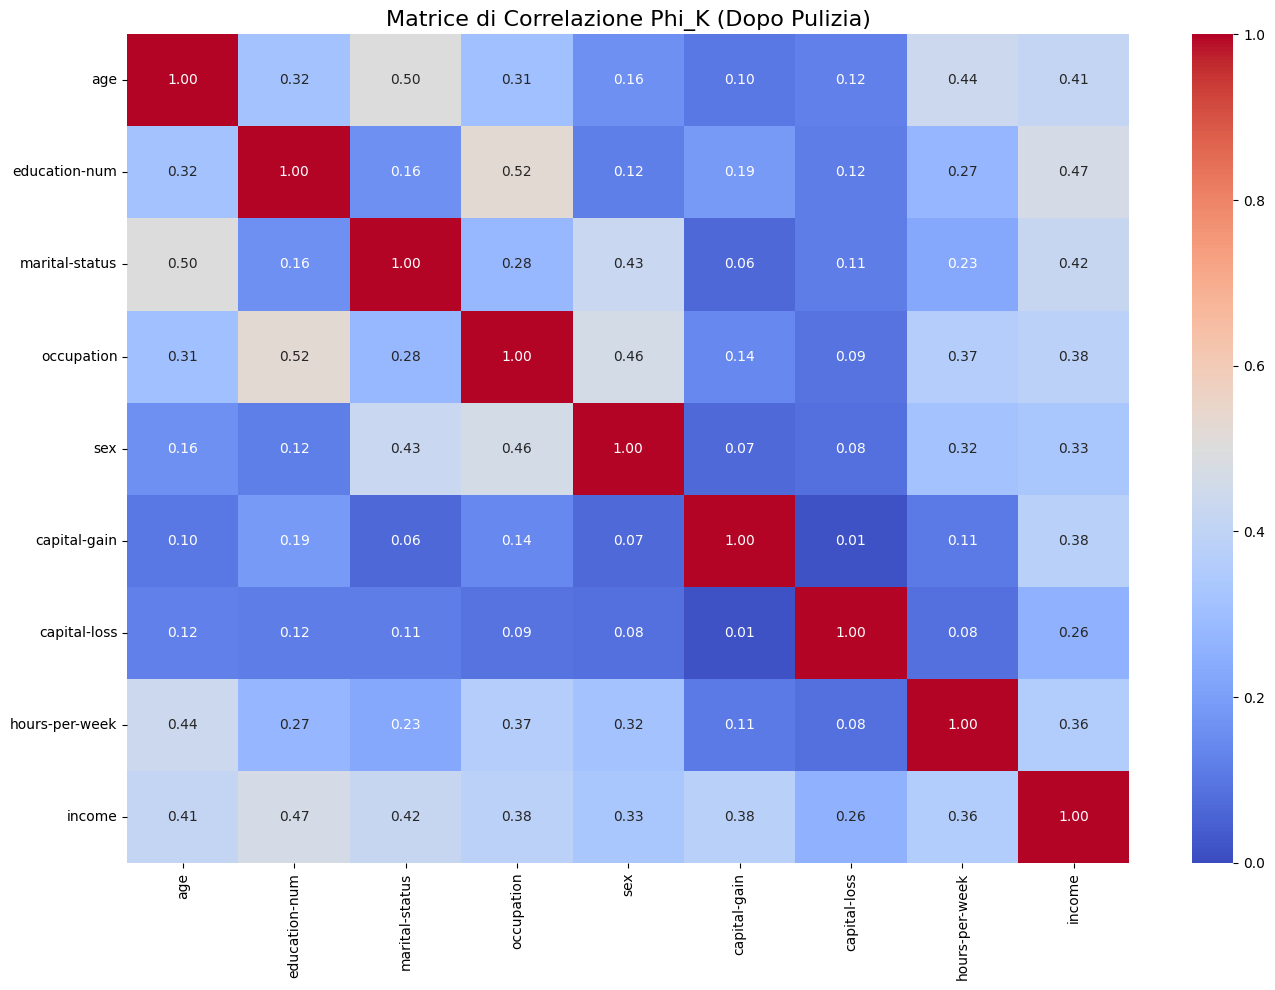

In [14]:
X_cleaned = X.drop(columns=['fnlwgt', 'race', 'native-country', 'education', 'relationship', 'workclass'])

complete_dataset_cleaned = pd.concat([X_cleaned, y_mapped], axis=1)
phik_matrix_cleaned = complete_dataset_cleaned.phik_matrix()
plt.figure(figsize=(14, 10))
sns.heatmap(phik_matrix_cleaned, annot=True, cmap='coolwarm', fmt=".2f", vmin=0, vmax=1)
plt.title('Matrice di Correlazione Phi_K (Dopo Pulizia)', fontsize=16)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Codifica delle variabili categoriche

Dopo la riduzione del dataset, possiamo modellare alcune variabili categoriche per favorire la comprensione del modello.

1. Mappatura di `sex`: in quanto è una variabile binaria, è stata mappata in formato numerico, con `Male` mappato a 1 e `Female` mappato a 0.

In [15]:
X_cleaned['sex_encoded'] = X_cleaned['sex'].map({'Male': 1, 'Female': 0})
X_cleaned = X_cleaned.drop(columns=['sex'])
X_cleaned.head()

,age,education-num,marital-status,occupation,capital-gain,capital-loss,hours-per-week,sex_encoded
0,39,13,Never-married,Adm-clerical,2174,0,40,1
1,50,13,Married-civ-spouse,Exec-managerial,0,0,13,1
2,38,9,Divorced,Handlers-cleaners,0,0,40,1
3,53,7,Married-civ-spouse,Handlers-cleaners,0,0,40,1
4,28,13,Married-civ-spouse,Prof-specialty,0,0,40,0


2. Codifica di `marital-status` e `occupation`: in quanto sono variabili categoriche con più di due categorie, sono state codificate usando la tecnica di One-Hot Encoding, che crea nuove variabili binarie per ogni categoria presente in ciascuna di queste feature.

Fonte: [Guide to Encoding Categorical Values in Python](https://pbpython.com/categorical-encoding.html)

In [16]:
cat_vars_to_encode = ['marital-status', 'occupation']
X_encoded = pd.get_dummies(X_cleaned, columns=cat_vars_to_encode, drop_first=True)

for col in X_encoded.columns:
    if X_encoded[col].dtype == 'bool':
        X_encoded[col] = X_encoded[col].astype(int)

print("Shape del dataset originale:", X.shape)
print("Shape del dataset pulito e codificato:", X_encoded.shape)
X_encoded.head()

Shape del dataset originale: (48842, 14)
Shape del dataset pulito e codificato: (48842, 26)


,age,education-num,capital-gain,capital-loss,hours-per-week,sex_encoded,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,...,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,occupation_Unknown
0,39,13,2174,0,40,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,50,13,0,0,13,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,38,9,0,0,40,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,53,7,0,0,40,1,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
4,28,13,0,0,40,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0


La tecnica di One-Hot Encoding ha comportato alla creazione di 12 nuove variabili binarie, che rappresentano ciascuna categoria presente nelle feature, `marital-status` e `occupation`. In questo modo però, il modello può basare le sue previsioni su variabili binarie piuttosto che su variabili categoriche.

### Standardizzazione dei dati
Ci sono variabili, soprattutto numeriche, che presentano dei range molto ampi, ad esempio `capital-gain` con valori che vanno da poco meno di 5000 fino a superare 40000.

Alcuni algoritmi (come SVM) sono sensibili a queste differenze di scala. Per risolvere il problema, è stata applicata la tecnica di standardizzazione, che trasforma i dati in modo che abbiano media 0 e deviazione standard 1. In questo modo, tutte le variabili numeriche saranno sulla stessa scala, migliorando le prestazioni del modello.

Le variabili create mediante One-Hot Encoding non necessitano di essere standardizzate, in quanto sono variabili binarie che assumono solo i valori 0 e 1.

Prima ancora di standardizzare i dati, è importante applicare la tecnica **Hold Out Validation**, permette di separare i dati in un set di training e uno di test. Si può decidere la percentuale da affidare a entrambi, l'approccio comune è assegnare l'80% dei dati al training set e il 20% al test set.

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_mapped, test_size=0.2, random_state=42, stratify=y_mapped)

column_to_scale = ['age', 'hours-per-week', 'education-num', 'capital-gain', 'capital-loss']

scaler = StandardScaler()
X_train[column_to_scale] = scaler.fit_transform(X_train[column_to_scale])
X_test[column_to_scale] = scaler.transform(X_test[column_to_scale])

print("Capital gain prima della standardizzazione:")
print(X_encoded['capital-gain'].head())

print("Capital gain dopo la standardizzazione: ")
print(X_train['capital-gain'].head())

Capital gain prima della standardizzazione:
0    2174
1       0
2       0
3       0
4       0
Name: capital-gain, dtype: int64
Capital gain dopo la standardizzazione: 
34495   -0.144075
18591   -0.144075
12562   -0.144075
552     -0.144075
3479    -0.144075
Name: capital-gain, dtype: float64


## Fase di Modellazione
In questa fase, vengono introdotti 2 modelli di classificazione: Support Vector Machine (SVM) e Random Forest.
La scelta di questi due modelli parte da un punto di vista personale, in quanto sono modelli che non ho mai utilizzato prima d'ora.

La SVM verte sul concetto di ipotesi di margine massimo, che cerca di trovare l'iperpiano che massimizza la distanza tra le classi nel spazio delle feature. La Random Forest è una 'foresta' di alberi decisionali, che combina le previsioni di più alberi per migliorare la precisione e ridurre il rischio di overfitting.

I parametri scelti per SVM sono:
- `max_iter=10000`: Questo parametro imposta il numero massimo di iterazioni che l'algoritmo SVM eseguirà durante l'addestramento. Un valore più alto consente all'algoritmo di convergere su soluzioni più complesse, ma potrebbe richiedere più tempo di addestramento. Il valore di default è 1000, ma in questo caso è stato aumentato a 10000 per garantire una migliore convergenza.
- `C=1.0`: Questo parametro 'dice' alla SVM quanto penalizzare gli errori di classificazione. Un valore più alto di C cerca di classificare correttamente tutti i punti di addestramento, mentre un valore più basso consente una maggiore tolleranza agli errori, favorendo una maggiore generalizzazione del modello. Il valore di default è 1.0.

I parametri scelti per Random Forest sono:
- `n_estimators=100`: Specifica il numero di alberi nella foresta. Un valore più alto generalmente porta a un modello più complesso e con prestazioni migliori, ma richiede più tempo di addestramento.
- `n_jobs=-1`: Questo parametro consente di utilizzare tutti i processori disponibili per l'addestramento del modello, accelerando il processo.

In [18]:
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

svm = LinearSVC(C=1.0, max_iter=10000, random_state=42, class_weight='balanced')
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')

### Baseline dei modelli
Per valutare le prestazioni iniziali dei modelli per fornire una baseline, entrambi i modelli vengono addestrati sul dataset ridotto, codificato e standardizzato. I risultati ottenuti verranno usati nella fase successiva di progetto, ovvero lo sporcamento del dataset.

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.79      0.86      7431
           1       0.55      0.84      0.67      2338

    accuracy                           0.80      9769
   macro avg       0.75      0.81      0.76      9769
weighted avg       0.85      0.80      0.81      9769



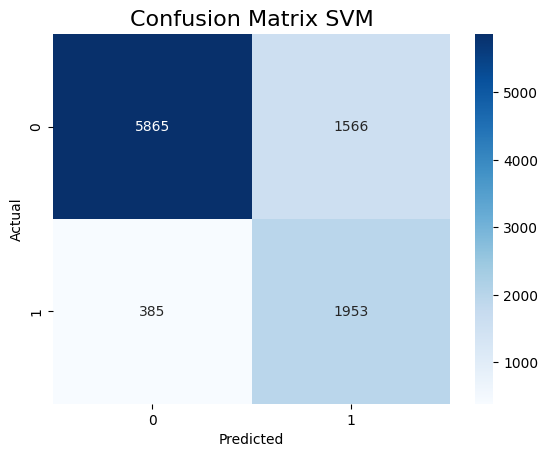

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))
cm1 = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix SVM', fontsize=16)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      7431
           1       0.67      0.68      0.67      2338

    accuracy                           0.84      9769
   macro avg       0.78      0.79      0.78      9769
weighted avg       0.84      0.84      0.84      9769

Confusion Matrix Random Forest:


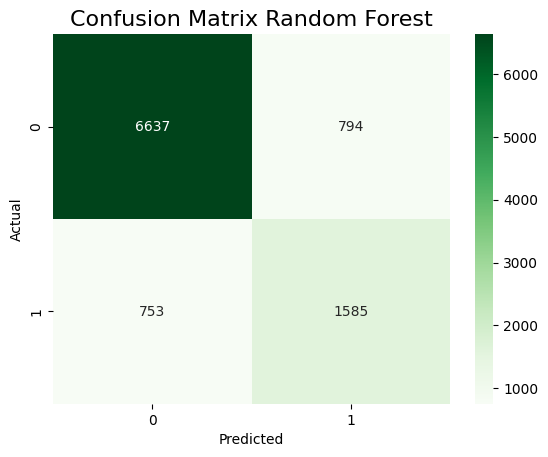

In [20]:
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix Random Forest:")
cm2 = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix Random Forest', fontsize=16)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Fase di sporcamento del dataset
Questa fase di progetto prevede la degradazione del dataset. L'obiettivo è valutare le performance dei modelli in condizioni di dati 'sporchi' o non perfetti, al fine di confrontare i risultati con quelli ottenuti nella fase di baseline e analizzare l'impatto del degrado dei dati sulle prestazioni dei modelli.

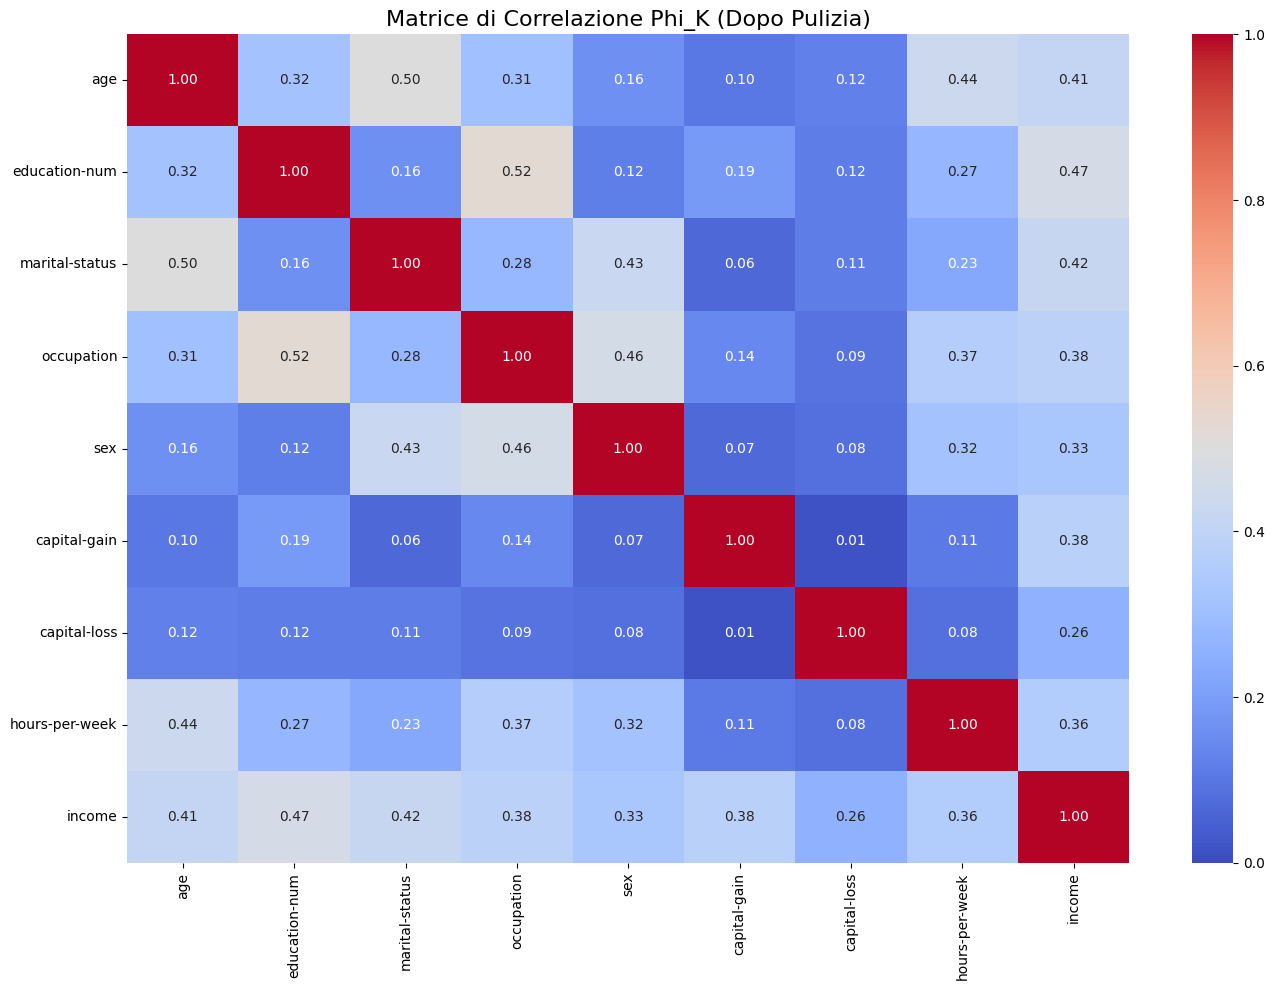

Le variabili soggette a sporcamento saranno quelle che dalla matrice di correlazione (ridotta) hanno presentato una moderata percentuale di correlazione con la variabile target `income`, ovvero:
- `age` (corr = 0.41)
- `education-num` (corr = 0.47)
- `marital-status` (corr = 0.42)
- `occupation` (corr = 0.38)
- `capital-gain` (corr = 0.38)
- `hours-per-week` (corr = 0.36)


### Rumore sui dati
Per introdurre rumore sui dati, viene usato il **Rumore Gaussiano**, che consiste nell'aggiungere un valore casuale estratto da una distribuzione normale (gaussiana) a ciascun dato. Questo tipo di rumore è comunemente usato per simulare errori di misurazione o variazioni naturali nei dati.

Questo approccio viene applicato solo alle variabili numeriche, in quanto è più adatto per introdurre rumore in dati continui.

Fonte: [Guide to Adding Noise to Synthetic Data using Python and Numpy](https://medium.com/@ms_somanna/guide-to-adding-noise-to-your-data-using-python-and-numpy-c8be815df524)

Per valutare l'impatto del rumore sui modelli, vengono creati 5 scenari, in cui viene introdotto un livello crescente di rumore sui dati.
Si tiene traccia delle 4 metriche più importanti, in modo da mostrare in un grafico l'andamento di ciascuna metrica al variare del livello di rumore introdotto sui dati.

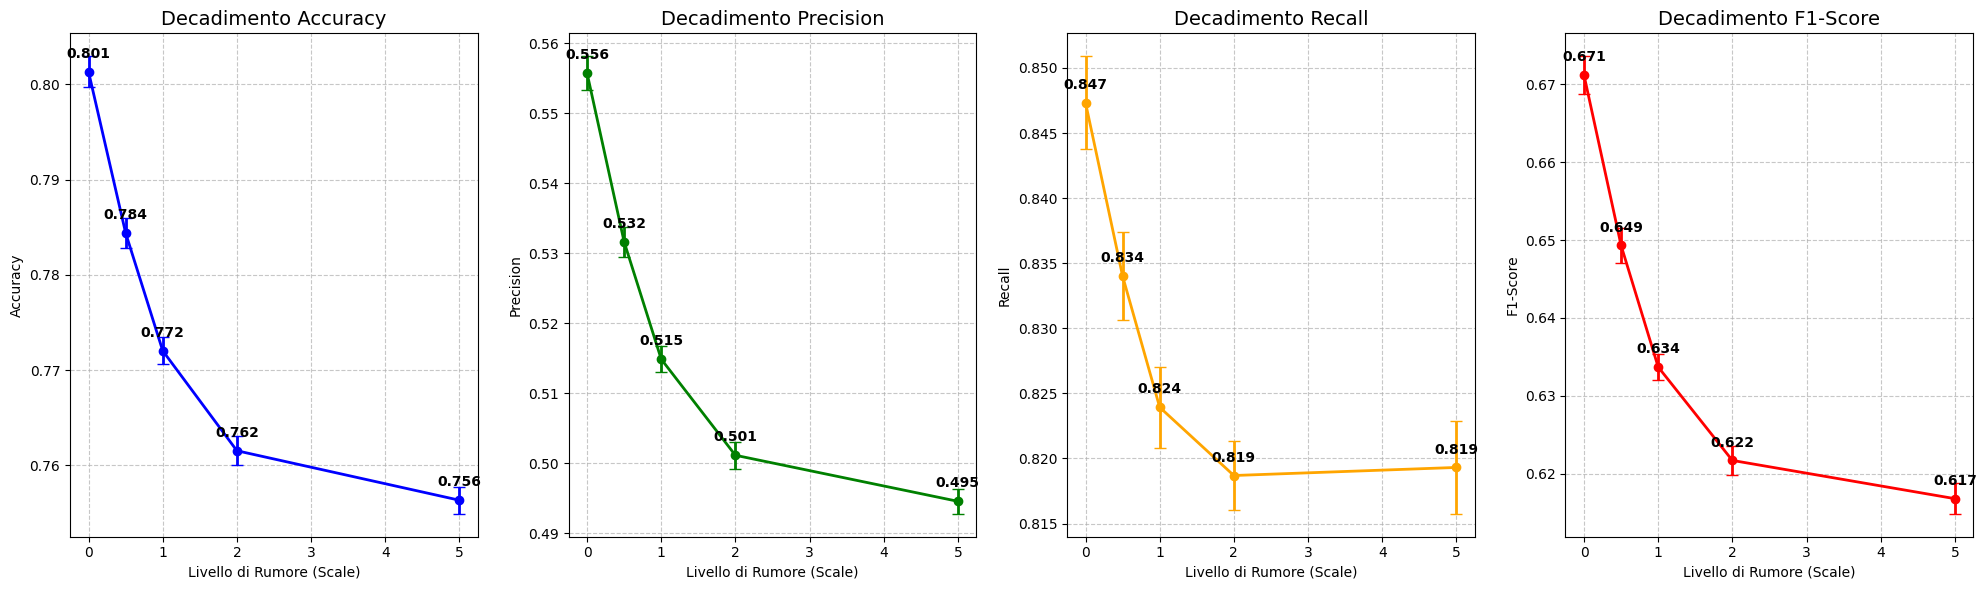

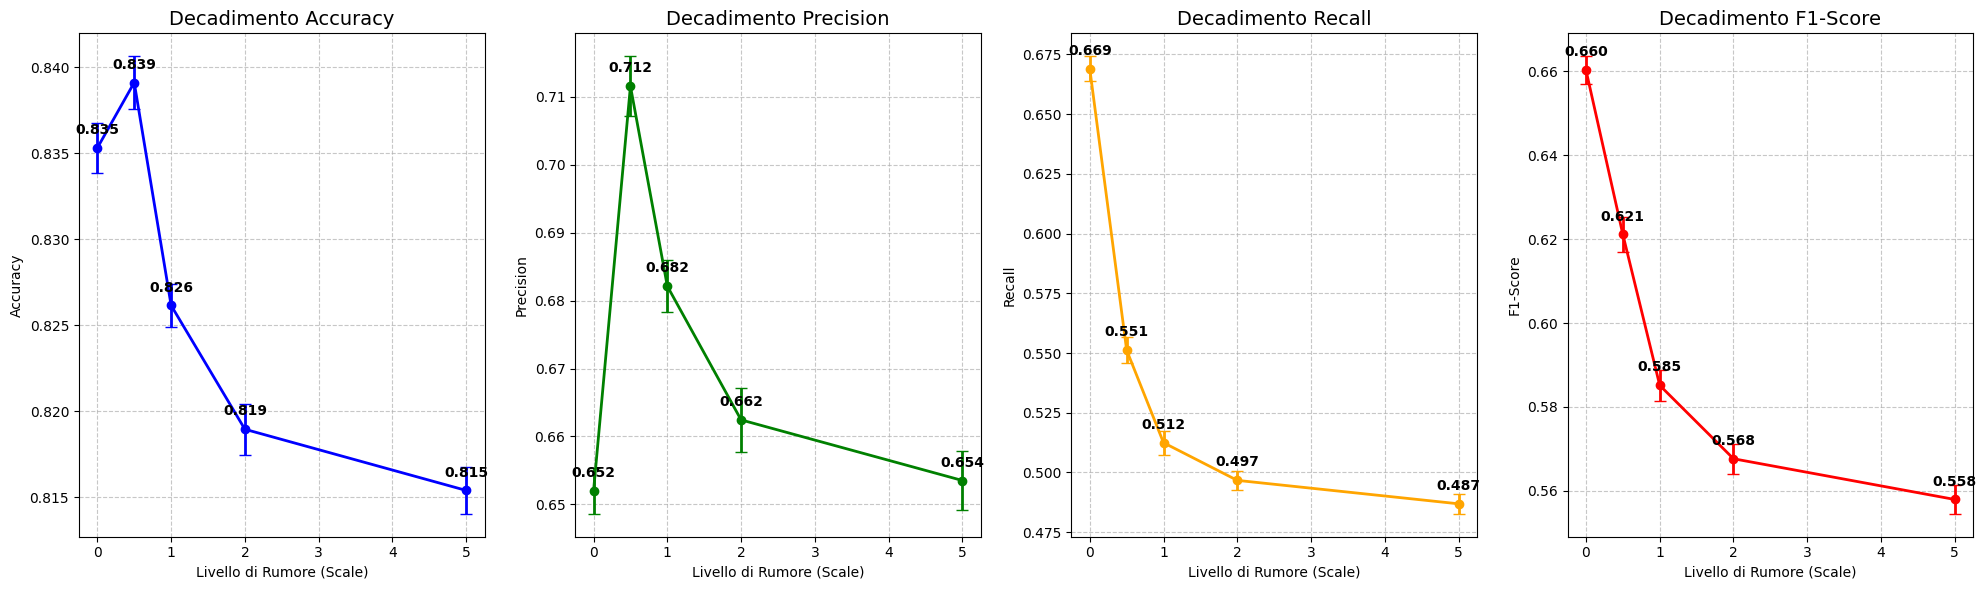

In [21]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
graph_colors = ['blue', 'green', 'orange', 'red']

def add_gaussian_noise(feature, noise_level, rng):
    return feature + rng.normal(0.0, noise_level, size=len(feature))

cols_to_scale = ['age', 'hours-per-week', 'education-num', 'capital-gain', 'capital-loss'] # per la svm 
cols_to_noise = ['age', 'education-num', 'hours-per-week', 'capital-gain']
noise_levels  = [0.0, 0.5, 1.0, 2.0, 5.0]
N = 20

acc_svm, prec_svm, rec_svm, f1_svm = [], [], [], []
acc_rf, prec_rf, rec_rf, f1_rf = [], [], [], []

for i in range(N):
    Xtr, Xte, ytr, yte = train_test_split(X_encoded, y_mapped, test_size=0.2,
                                          random_state=i, stratify=y_mapped)

    Xtr, Xte = Xtr.copy(), Xte.copy()
    scaler = StandardScaler()
    Xtr[cols_to_scale] = scaler.fit_transform(Xtr[cols_to_scale])
    Xte[cols_to_scale] = scaler.transform(Xte[cols_to_scale])

    rng = np.random.default_rng(i)
    for level in noise_levels:
        Xtr_noisy, Xte_noisy = Xtr.copy(), Xte.copy()
        for col in cols_to_noise:
            Xtr_noisy[col] = add_gaussian_noise(Xtr_noisy[col], level, rng)
            Xte_noisy[col] = add_gaussian_noise(Xte_noisy[col], level, rng)

        svm.fit(Xtr_noisy, ytr)
        y_pred_svm = svm.predict(Xte_noisy)
        acc_svm.append(accuracy_score(yte, y_pred_svm))
        prec_svm.append(precision_score(yte, y_pred_svm, zero_division=0))
        rec_svm.append(recall_score(yte, y_pred_svm, zero_division=0))
        f1_svm.append(f1_score(yte, y_pred_svm, zero_division=0))

        rf.fit(Xtr_noisy, ytr)
        yp = rf.predict(Xte_noisy)
        acc_rf.append(accuracy_score(yte, yp))
        prec_rf.append(precision_score(yte, yp, zero_division=0))
        rec_rf.append(recall_score(yte, yp, zero_division=0))
        f1_rf.append(f1_score(yte, yp, zero_division=0))

def avg_ig(val):
    val = np.array(val).reshape(N, len(noise_levels))
    media = val.mean(axis=0)
    ic = 1.96 * val.std(axis=0, ddof=1) / np.sqrt(N)
    return media, ic

avg_svm, ics_svm = [], []
for metrics in [acc_svm, prec_svm, rec_svm, f1_svm]:
    m, c = avg_ig(metrics)
    avg_svm.append(m); 
    ics_svm.append(c)

avg_rf, ics_rf = [], []
for metrics in [acc_rf, prec_rf, rec_rf, f1_rf]:
    m, c = avg_ig(metrics)
    avg_rf.append(m); 
    ics_rf.append(c)

def plot_metrics_line(x_values, avg, ics, x_label):
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    for i, ax in enumerate(axes):
        ax.errorbar(x_values, avg[i], yerr=ics[i], marker='o',
                    color=graph_colors[i], linewidth=2, capsize=4)
        for x, yv in zip(x_values, avg[i]):
            ax.annotate(f"{yv:.3f}", (x, yv), textcoords="offset points",
                        xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')
        ax.set_title(f'Decadimento {metric_names[i]}', fontsize=14)
        ax.set_xlabel(x_label)
        ax.set_ylabel(metric_names[i])
        ax.grid(True, ls='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_metrics_line(noise_levels, avg_svm, ics_svm, 'Livello di Rumore (Scale)')
plot_metrics_line(noise_levels, avg_rf, ics_rf, 'Livello di Rumore (Scale)')

### Rimozione casuale di feature
Mentre il rumore gaussiano coinvolgeva solamente variabili numeriche, questa tecnica è in grado di includere anche le variabili categoriche.

La scelta delle feature da rimuovere è stata fatta in base alla matrice di correlazione, scegliendo in modo casuale le variabili con una correlazione moderata con la variabile target `income` in aggiunta a una possibile correlazione con altre variabili:
- `capital-loss` (corr = 0.26)
- `sex` (corr = 0.33)
- `hours-per-week` (corr = 0.36)
- `capital-gain` (corr = 0.38)
- `age` (corr = 0.41)
- `marital-status` (corr = 0.42)
- `occupation` (corr = 0.44)
- `education-num` (corr = 0.47)


Bisogna ricordare che per alcune variabili categoriche è stata applicata la tecnica di One-Hot Encoding, che ha comportato alla creazione di nuove variabili binarie per ogni categoria presente in ciascuna di queste feature. In questo caso, la rimozione di una feature categorica comporta anche la rimozione di tutte le variabili binarie create.


Test 1: ['age']
Test 2: ['occupation', 'education-num', 'capital-loss']
Test 3: ['education-num']
Test 4: ['age', 'sex_encoded', 'capital-loss', 'education-num']
Test 5: ['age', 'capital-gain']


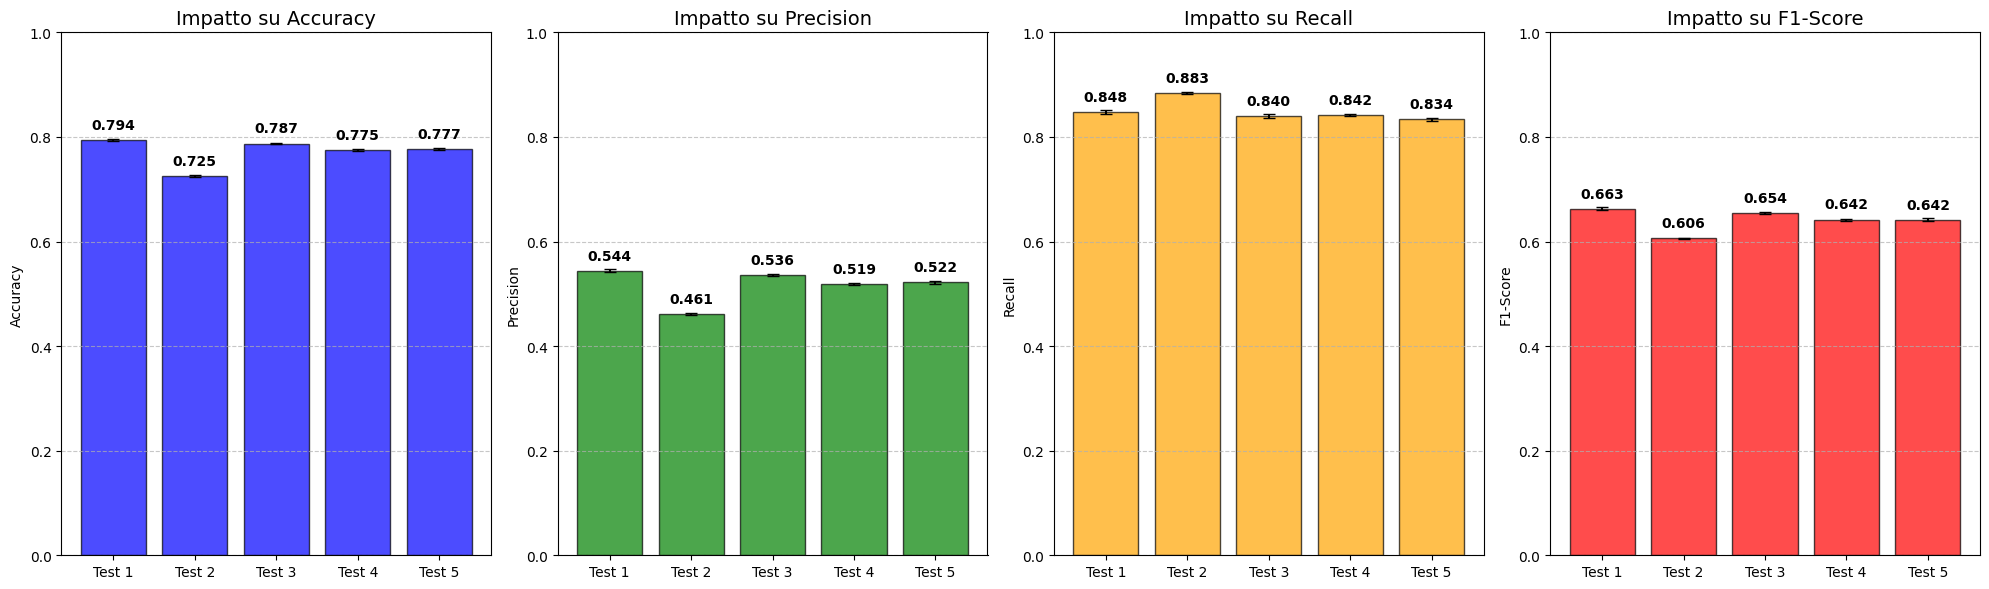

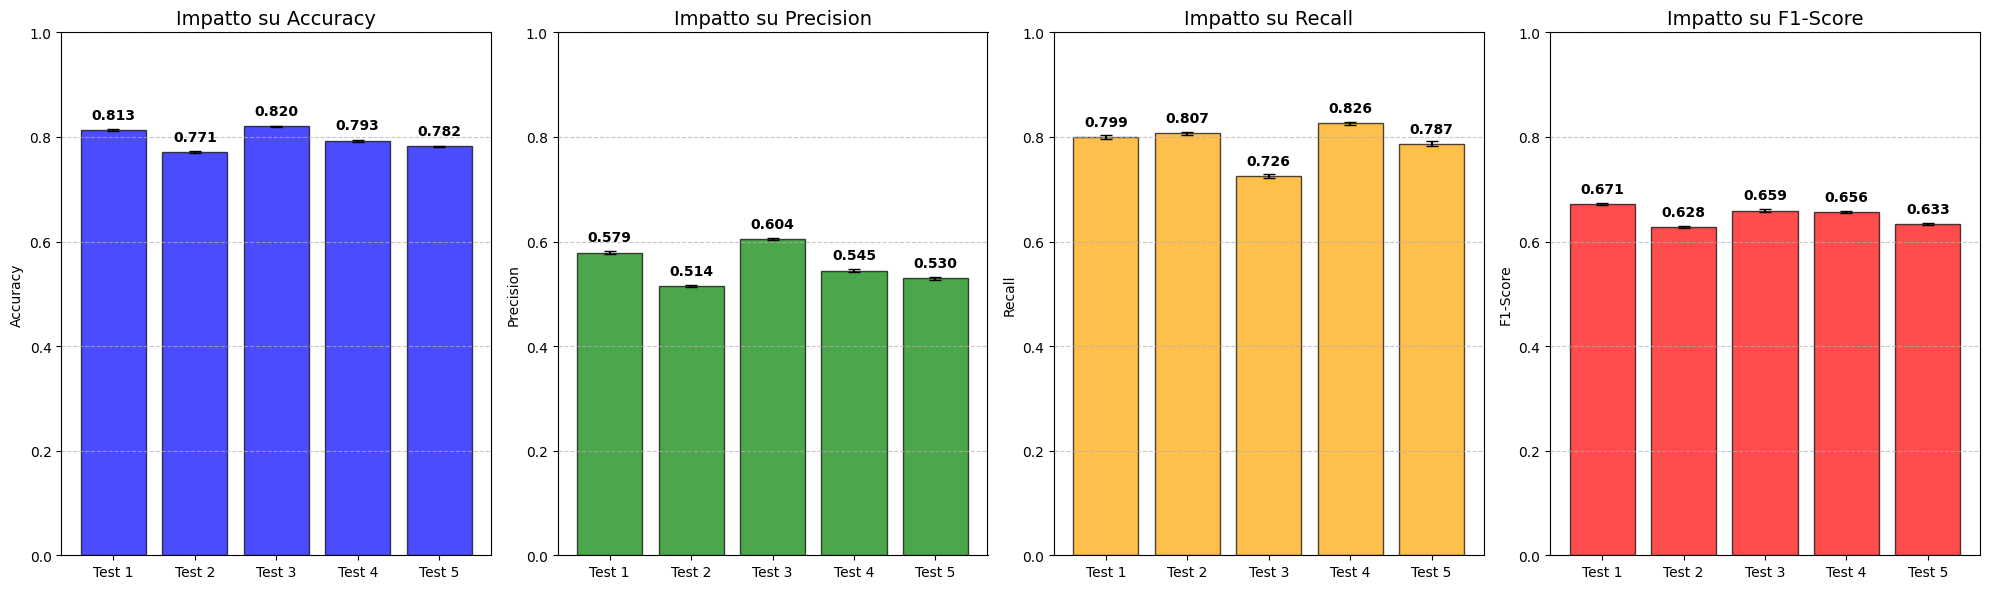

In [22]:
import random as rnd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc_svm, prec_svm, rec_svm, f1_svm = [], [], [], []
acc_rf, prec_rf, rec_rf, f1_rf = [], [], [], []

base_features = ['age', 'education-num', 'marital-status', 'occupation',
                 'capital-gain', 'hours-per-week', 'capital-loss', 'sex_encoded']

num_tests = 5

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
graph_colors = ['blue', 'green', 'orange', 'red']

rnd.seed(42)
all_tests = [rnd.sample(base_features, rnd.randint(1, 4)) for _ in range(num_tests)]

for i in range(num_tests):
    print(f"Test {i+1}: {all_tests[i]}")
    
N = 20

for i in range(num_tests):
    base_features_to_drop = all_tests[i]
    
    # Rimozione per One Hot Encoding
    columns_to_drop = []
    for base_feat in base_features_to_drop:
        cols = [c for c in X_train.columns if c == base_feat or c.startswith(base_feat + '_')]
        columns_to_drop.extend(cols)
        
    for j in range(N):
        Xtr, Xte, ytr, yte = train_test_split(X_encoded, y_mapped, test_size=0.2,
                                          random_state=j, stratify=y_mapped)
        
        Xtr_cleaned = Xtr.drop(columns=columns_to_drop) 
        Xte_cleaned = Xte.drop(columns=columns_to_drop)
        
        cols_present = [col for col in cols_to_scale if col in Xtr_cleaned.columns]
        scaler = StandardScaler()
        Xtr_cleaned[cols_present] = scaler.fit_transform(Xtr_cleaned[cols_present])
        Xte_cleaned[cols_present] = scaler.transform(Xte_cleaned[cols_present])
        
        svm.fit(Xtr_cleaned, ytr)
        y_pred_svm = svm.predict(Xte_cleaned)
        acc_svm.append(accuracy_score(yte, y_pred_svm))
        prec_svm.append(precision_score(yte, y_pred_svm, zero_division=0))
        rec_svm.append(recall_score(yte, y_pred_svm, zero_division=0))
        f1_svm.append(f1_score(yte, y_pred_svm, zero_division=0))
        
        rf.fit(Xtr_cleaned, ytr)
        y_pred_rf = rf.predict(Xte_cleaned)
        acc_rf.append(accuracy_score(yte, y_pred_rf))
        prec_rf.append(precision_score(yte, y_pred_rf, zero_division=0))
        rec_rf.append(recall_score(yte, y_pred_rf, zero_division=0))
        f1_rf.append(f1_score(yte, y_pred_rf, zero_division=0))
        

def avg_ig(val):
    val = np.array(val).reshape(num_tests, N)
    media = val.mean(axis=1)
    ic = 1.96 * val.std(axis=1, ddof=1) / np.sqrt(N)
    return media, ic

avg_svm, ics_svm = [], []
for metrics in [acc_svm, prec_svm, rec_svm, f1_svm]:
    m, c = avg_ig(metrics)
    avg_svm.append(m); 
    ics_svm.append(c)

avg_rf, ics_rf = [], []
for metrics in [acc_rf, prec_rf, rec_rf, f1_rf]:
    m, c = avg_ig(metrics)
    avg_rf.append(m); 
    ics_rf.append(c)

def plot_metrics_bar(x_labels, avg, ics, x_label):
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    xpos = np.arange(len(x_labels))
    for i, ax in enumerate(axes):
        ax.bar(xpos, avg[i], yerr=ics[i], color=graph_colors[i], alpha=0.7,
               edgecolor='black', capsize=4)
        for x, yv in zip(xpos, avg[i]):
            ax.annotate(f"{yv:.3f}", (x, yv), textcoords="offset points",
                        xytext=(0, 8), ha='center', fontsize=10, fontweight='bold')
        ax.set_title(f'Impatto su {metric_names[i]}', fontsize=14)
        ax.set_xticks(xpos); ax.set_xticklabels(x_labels)
        ax.set_ylabel(metric_names[i]); ax.set_ylim(0, 1.0)
        ax.grid(axis='y', ls='--', alpha=0.7)
    plt.tight_layout(); plt.show()

x_labels = [f"Test {i+1}" for i in range(num_tests)]

plot_metrics_bar(x_labels, avg_svm, ics_svm, 'Test')
plot_metrics_bar(x_labels, avg_rf,  ics_rf,  'Test')


### Sostituzione di valori con valori casuali
Per questa tecnica, vengono selezionate le feature usate precedentemente per la fase di rimozione, in particolare le tre più correlate con la variabile target `income`, ovvero:
- `education-num` (corr = 0.47)
- `occupation` (corr = 0.44)
- `marital-status` (corr = 0.42)

L'obiettivo è sostituire con valori casuali i dati presenti in queste feature. 

Per le variabili numeriche, dato che sono state standardizzate, un approccio ottimale è lo shuffling dei dati, ovvero sostituire i valori della feature con valori appartenenti ad altre righe, in altre parole, assegnare in modo casuale il valore di un utente a un altro utente.

Per le variabili categoriche, in precedenza era stato applicata la tecnica di One-Hot Encoding (e poi mappate le nuove colonne in formato binario), l'approccio migliore è fare in modo di rimpiazzare il valore settato a 1 (che indica la categoria a cui appartiene l'utente) a 0, e in modo casuale assegnare il valore 1 a un'altra colonna della stessa categoria.

In [23]:
print("Esempio: colonne generate da One-Hot Encoding per occupation")
[col for col in X_encoded.columns if col.startswith('occupation_')]

Esempio: colonne generate da One-Hot Encoding per occupation


['occupation_Armed-Forces',
 'occupation_Craft-repair',
 'occupation_Exec-managerial',
 'occupation_Farming-fishing',
 'occupation_Handlers-cleaners',
 'occupation_Machine-op-inspct',
 'occupation_Other-service',
 'occupation_Priv-house-serv',
 'occupation_Prof-specialty',
 'occupation_Protective-serv',
 'occupation_Sales',
 'occupation_Tech-support',
 'occupation_Transport-moving',
 'occupation_Unknown']

Come per le precedenti tecniche, verranno eseguiti 5 scenari, in questo caso basato sulla percentuale di valori casuali introdotti nelle feature, in modo da mostrare in un grafico l'andamento di ciascuna metrica al variare della percentuale.

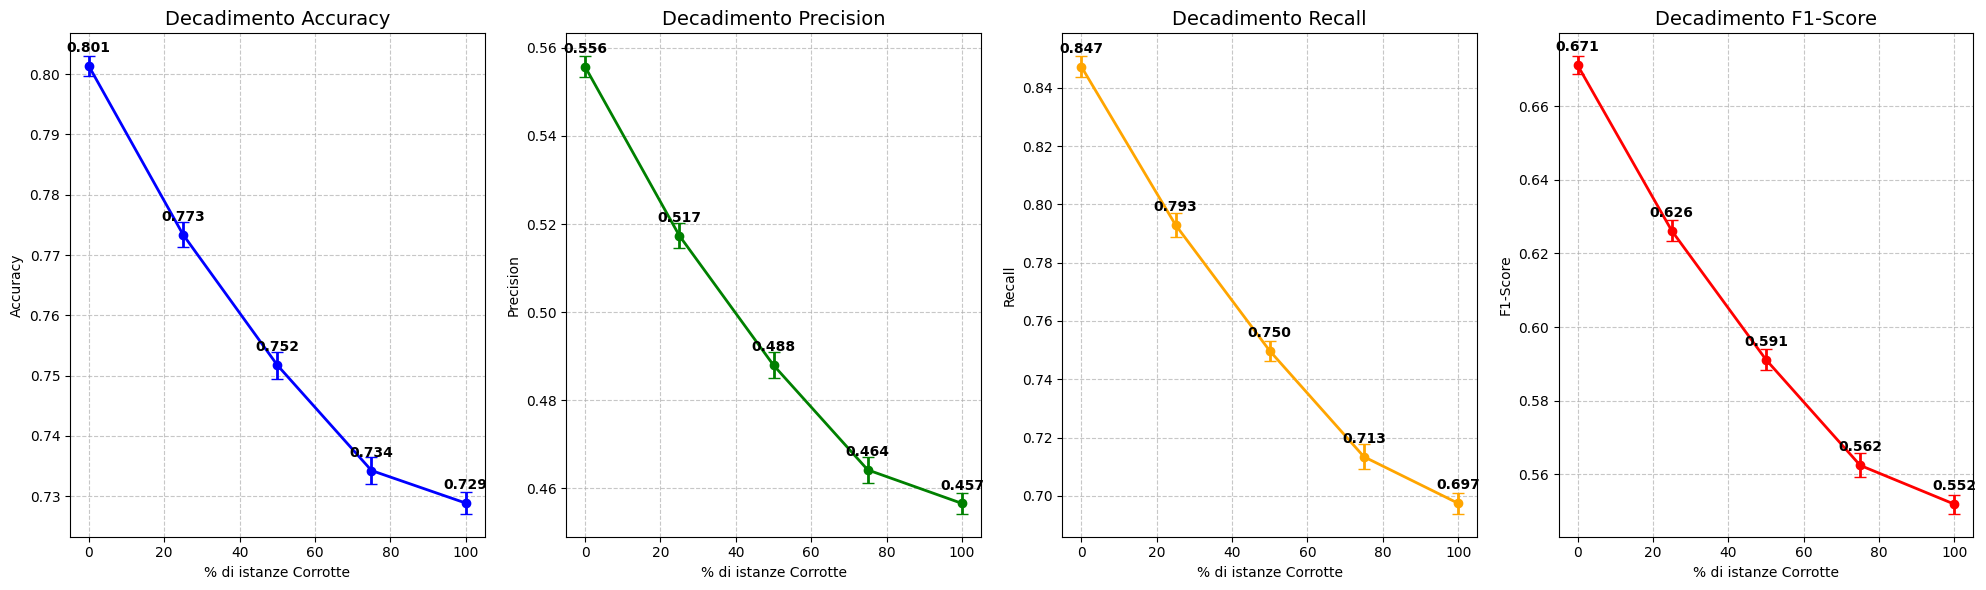

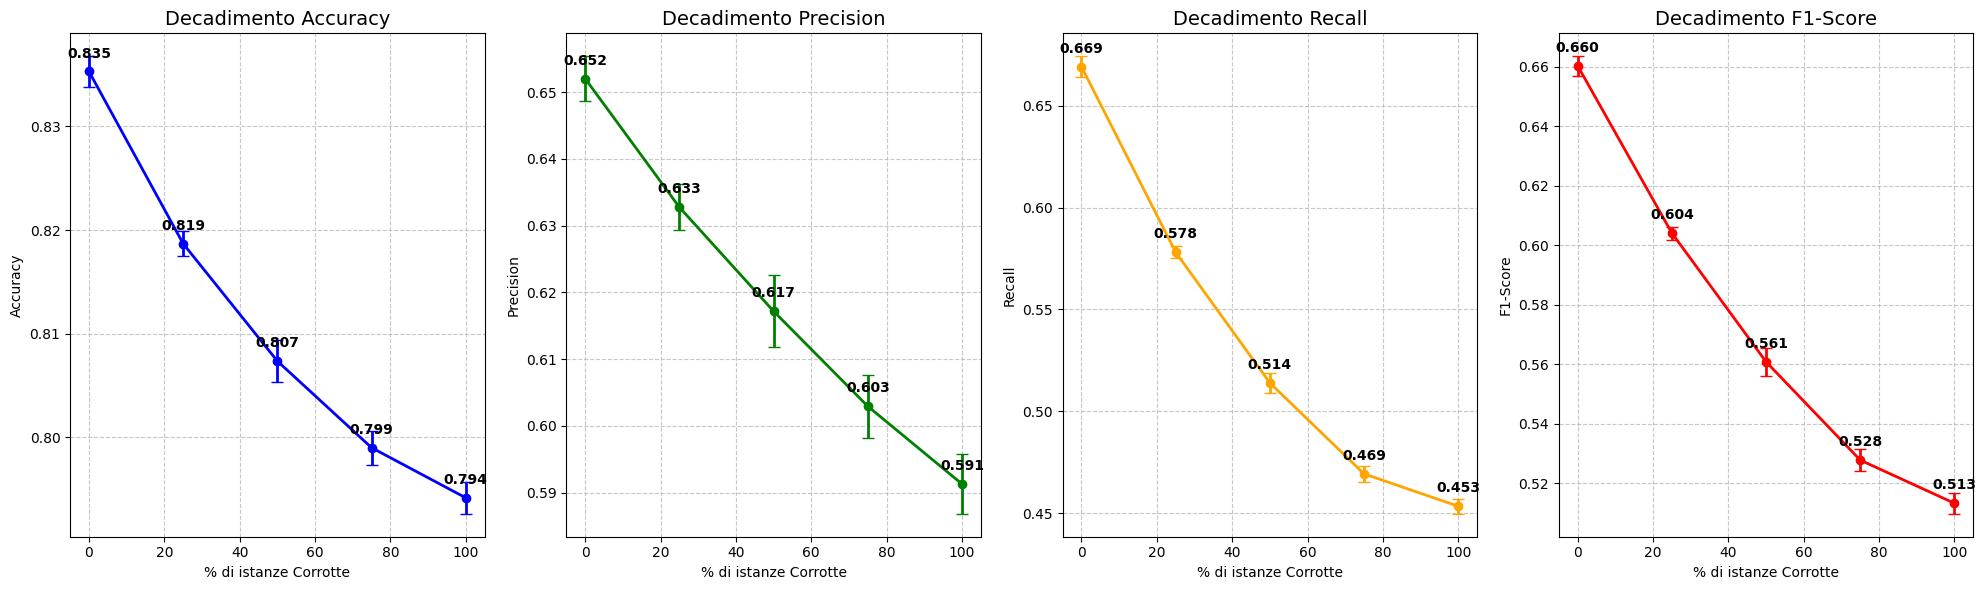

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc_svm, prec_svm, rec_svm, f1_svm = [], [], [], []
acc_rf,  prec_rf,  rec_rf,  f1_rf  = [], [], [], []

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
graph_colors = ['blue', 'green', 'orange', 'red']

cols_to_scale = ['age', 'hours-per-week', 'education-num', 'capital-gain', 'capital-loss']
important_features = ['education-num', 'occupation', 'marital-status']
percentages = [0.0, 0.25, 0.5, 0.75, 1.0]
N = 20

def shuffle_numerical_feature(column, pct, rng):
    result = column.copy()
    num_rows_to_shuffle = int(len(column) * pct)
    if num_rows_to_shuffle == 0:
        return result
    idx = rng.choice(column.index, num_rows_to_shuffle, replace=False)
    result.loc[idx] = rng.permutation(column.loc[idx].values)
    return result

def shuffle_categorical_onehot(df, base_feature, pct, rng): # df = tutto il dataset
    result = df.copy()
    cols = [c for c in result.columns if c.startswith(base_feature + '_')]
    num_rows_to_shuffle = int(len(result) * pct)
    if not cols or num_rows_to_shuffle == 0:
        return result
    idx = rng.choice(result.index, num_rows_to_shuffle, replace=False)
    result.loc[idx, cols] = 0
    new_cat = rng.choice(cols, num_rows_to_shuffle)
    
    matrix = result[cols].to_numpy(copy=True)

    # Pone a 1 la nuova categoria
    row_pos = result.index.get_indexer(idx)
    col_index = {c: k for k, c in enumerate(cols)}
    col_pos = np.array([col_index[c] for c in new_cat])
    
    matrix[row_pos, col_pos] = 1
    result[cols] = matrix
    
    return result

for j in range(N):
    Xtr, Xte, ytr, yte = train_test_split(X_encoded, y_mapped, test_size=0.2,
                                          random_state=j, stratify=y_mapped)
    
    Xtr, Xte = Xtr.copy(), Xte.copy()
    scaler = StandardScaler()
    Xtr[cols_to_scale] = scaler.fit_transform(Xtr[cols_to_scale])
    Xte[cols_to_scale] = scaler.transform(Xte[cols_to_scale])

    rng = np.random.default_rng(j)
    for pct in percentages:
        Xtr_copy, Xte_copy = Xtr.copy(), Xte.copy()
        if pct > 0.0:
            for feature in important_features:
                if feature == 'education-num':
                    Xtr_copy[feature] = shuffle_numerical_feature(Xtr_copy[feature], pct, rng)
                    Xte_copy[feature] = shuffle_numerical_feature(Xte_copy[feature], pct, rng)
                else:
                    Xtr_copy = shuffle_categorical_onehot(Xtr_copy, feature, pct, rng)
                    Xte_copy = shuffle_categorical_onehot(Xte_copy, feature, pct, rng)

        svm.fit(Xtr_copy, ytr)
        yp = svm.predict(Xte_copy)
        acc_svm.append(accuracy_score(yte, yp))
        prec_svm.append(precision_score(yte, yp, zero_division=0))
        rec_svm.append(recall_score(yte, yp, zero_division=0))
        f1_svm.append(f1_score(yte, yp, zero_division=0))

        rf.fit(Xtr_copy, ytr)
        yp = rf.predict(Xte_copy)
        acc_rf.append(accuracy_score(yte, yp))
        prec_rf.append(precision_score(yte, yp, zero_division=0))
        rec_rf.append(recall_score(yte, yp, zero_division=0))
        f1_rf.append(f1_score(yte, yp, zero_division=0))

def avg_ig(val):
    val = np.array(val).reshape(N, len(percentages))
    media = val.mean(axis=0)
    ic = 1.96 * val.std(axis=0, ddof=1) / np.sqrt(N)
    return media, ic

avg_svm, ics_svm = [], []
for metrics in [acc_svm, prec_svm, rec_svm, f1_svm]:
    m, c = avg_ig(metrics); avg_svm.append(m); ics_svm.append(c)

avg_rf, ics_rf = [], []
for metrics in [acc_rf, prec_rf, rec_rf, f1_rf]:
    m, c = avg_ig(metrics); avg_rf.append(m); ics_rf.append(c)

def plot_metrics_line(x_values, avg, ics, x_label):
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    for i, ax in enumerate(axes):
        ax.errorbar(x_values, avg[i], yerr=ics[i], marker='o',
                    color=graph_colors[i], linewidth=2, capsize=4)
        for x, yv in zip(x_values, avg[i]):
            ax.annotate(f"{yv:.3f}", (x, yv), textcoords="offset points",
                        xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')
        ax.set_title(f'Decadimento {metric_names[i]}', fontsize=14)
        ax.set_xlabel(x_label); ax.set_ylabel(metric_names[i])
        ax.grid(True, ls='--', alpha=0.7)
    plt.tight_layout(); plt.show()

x_pct = [int(p*100) for p in percentages]   # 0, 25, 50, 75, 100
plot_metrics_line(x_pct, avg_svm, ics_svm, '% di istanze Corrotte')
plot_metrics_line(x_pct, avg_rf,  ics_rf,  '% di istanze Corrotte')